In [32]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import random
# import numpy as np
# from collections import deque
# from gym_sepsis.envs.sepsis_env import SepsisEnv

In [33]:
# env = SepsisEnv()

In [34]:
from gym_sepsis.envs.sepsis_env import SepsisEnv
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Device setup
# -----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------------------------------
# Environment setup
# -----------------------------------------------------
env = SepsisEnv()

reset_output = env.reset()
if isinstance(reset_output, tuple):
    state = reset_output[0]
else:
    state = reset_output
state = np.array(state).flatten()

state_size = len(state)
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

# -----------------------------------------------------
# Q-network (shared by online and target)
# -----------------------------------------------------
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, layers=3, hidden=128):
        super(QNetwork, self).__init__()
        self.fc_in = nn.Linear(state_size, hidden)
        self.fc = nn.ModuleList()
        for _ in range(layers):
            self.fc.append(nn.Linear(hidden, hidden))
        self.fc_out = nn.Linear(hidden, action_size)

    def forward(self, x):
        x = torch.relu(self.fc_in(x))
        for layer in self.fc:
            x = torch.relu(layer(x))
        return self.fc_out(x)

# -----------------------------------------------------
# Hyperparameters
# -----------------------------------------------------
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.005
epsilon_decay = 0.9995
lr = 1e-3
batch_size = 64
memory_size = 20000
num_episodes = 1000
target_update_freq = 10
eval_episodes = 100  # number of episodes for testing

# -----------------------------------------------------
# Initialize networks, optimizer, memory
# -----------------------------------------------------
policy_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
loss_fn = nn.MSELoss()
memory = deque(maxlen=memory_size)

# -----------------------------------------------------
# Helper functions
# -----------------------------------------------------
def get_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return torch.argmax(q_values).item()

def replay():
    if len(memory) < batch_size:
        return None
    
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # Q-learning (Double DQN)
    q_values = policy_net(states).gather(1, actions)
    next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
    next_q_values = target_net(next_states).gather(1, next_actions).detach()
    target_q = rewards + (gamma * next_q_values * (1 - dones))

    loss = loss_fn(q_values, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# -----------------------------------------------------
# Training loop
# -----------------------------------------------------
reward_history, loss_history, episode_length = [], [], []
epsilon_history, action_counts = [], np.zeros(action_size, dtype=int)

for episode in range(num_episodes):
    reset_output = env.reset()
    state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
    state = np.array(state).flatten()
    done, total_reward, steps = False, 0, 0
    episode_losses = []

    while not done:
        action = get_action(state, epsilon)
        step_output = env.step(action)
        if len(step_output) == 5:
            next_state, reward, terminated, truncated, info = step_output
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_output
        next_state = np.array(next_state).flatten()

        memory.append((state, action, reward, next_state, float(done)))
        state = next_state
        total_reward += reward
        steps += 1
        action_counts[action] += 1

        loss_val = replay()
        if loss_val is not None:
            episode_losses.append(loss_val)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    reward_history.append(total_reward)
    epsilon_history.append(epsilon)
    episode_length.append(steps)
    loss_history.append(np.mean(episode_losses) if episode_losses else 0)

    print(f"Episode {episode+1}/{num_episodes} | Reward: {total_reward:.2f} | Steps: {steps} | Eps: {epsilon:.3f}")

# -----------------------------------------------------
# Evaluation (ε = 0)
# -----------------------------------------------------
def evaluate_policy(env, model, episodes=20):
    rewards, lengths = [], []
    action_counts_eval = np.zeros(action_size, dtype=int)

    model.eval()
    with torch.no_grad():
        for ep in range(episodes):
            reset_output = env.reset()
            state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
            state = np.array(state).flatten()
            done, total_reward, steps = False, 0, 0

            while not done:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = model(state_t)
                action = torch.argmax(q_values).item()

                step_output = env.step(action)
                if len(step_output) == 5:
                    next_state, reward, terminated, truncated, info = step_output
                    done = terminated or truncated
                else:
                    next_state, reward, done, info = step_output

                next_state = np.array(next_state).flatten()
                state = next_state
                total_reward += reward
                steps += 1
                action_counts_eval[action] += 1

            rewards.append(total_reward)
            lengths.append(steps)
            print(f"Eval Episode {ep+1}/{episodes} | Reward: {total_reward:.2f} | Steps: {steps}")

    return np.mean(rewards), np.std(rewards), np.mean(lengths), np.std(lengths), action_counts_eval

mean_r, std_r, mean_l, std_l, eval_actions = evaluate_policy(env, policy_net, episodes=eval_episodes)
print(f"\nEvaluation over {eval_episodes} episodes:")
print(f"Avg Reward: {mean_r:.2f} ± {std_r:.2f}")
print(f"Avg Length: {mean_l:.2f} ± {std_l:.2f}")


Using device: cpu


State size: 46
Action size: 24
Episode 1/1000 | Reward: 15.00 | Steps: 10 | Eps: 1.000
Episode 2/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.999
Episode 3/1000 | Reward: 15.00 | Steps: 8 | Eps: 0.999
Episode 4/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.998
Episode 5/1000 | Reward: 15.00 | Steps: 9 | Eps: 0.998
Episode 6/1000 | Reward: -15.00 | Steps: 10 | Eps: 0.997
Episode 7/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.997
Episode 8/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.996
Episode 9/1000 | Reward: -15.00 | Steps: 9 | Eps: 0.996
Episode 10/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.995
Episode 11/1000 | Reward: 15.00 | Steps: 9 | Eps: 0.995
Episode 12/1000 | Reward: 15.00 | Steps: 9 | Eps: 0.994
Episode 13/1000 | Reward: 15.00 | Steps: 9 | Eps: 0.994
Episode 14/1000 | Reward: 15.00 | Steps: 9 | Eps: 0.993
Episode 15/1000 | Reward: 15.00 | Steps: 9 | Eps: 0.993
Episode 16/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.992
Episode 17/1000 | Reward: 15.00 | Steps: 10 | Eps: 0.992
Episode 18/1000

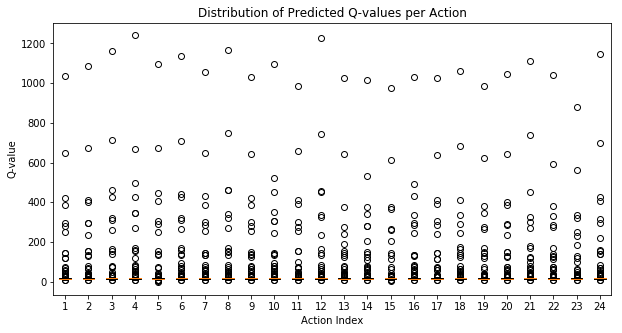

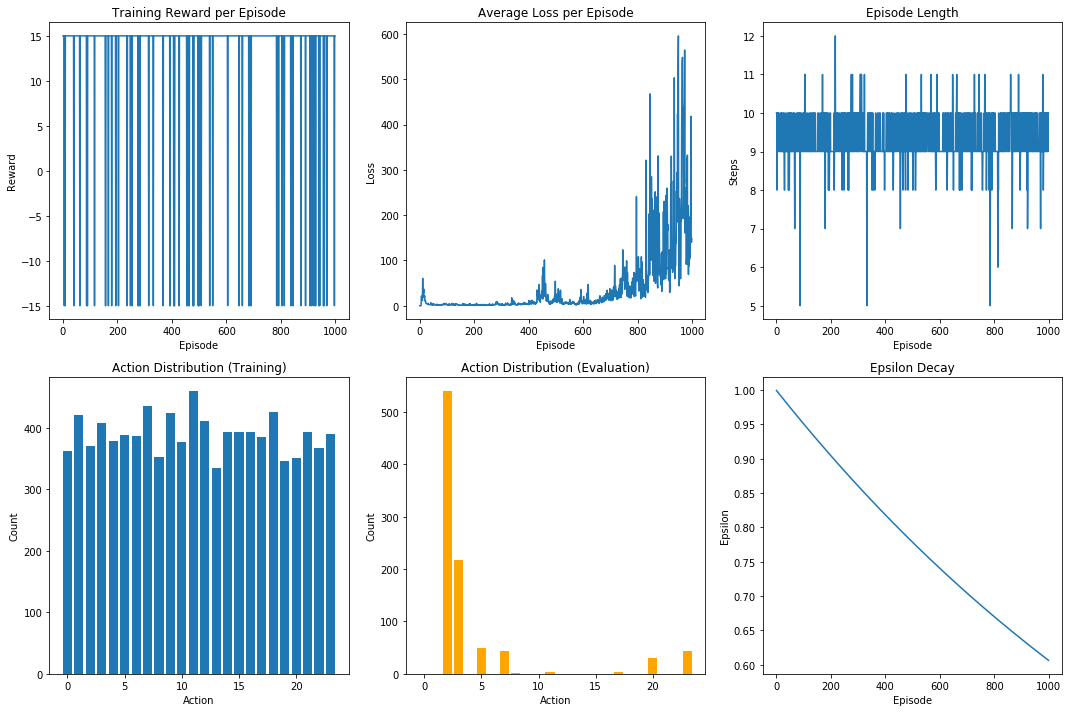

In [35]:
# -----------------------------------------------------
# Q-value landscape inspection
# -----------------------------------------------------
def visualize_q_distribution(model, n_samples=200):
    """Plots distribution of Q-values over random sampled states."""
    sampled_states = []
    for _ in range(n_samples):
        reset_output = env.reset()
        s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        sampled_states.append(np.array(s).flatten())
    states_t = torch.FloatTensor(np.vstack(sampled_states)).to(device)
    with torch.no_grad():
        q_vals = model(states_t).cpu().numpy()
    plt.figure(figsize=(10,5))
    plt.boxplot(q_vals)
    plt.title("Distribution of Predicted Q-values per Action")
    plt.xlabel("Action Index")
    plt.ylabel("Q-value")
    plt.show()

visualize_q_distribution(policy_net)

# -----------------------------------------------------
# Performance visualization
# -----------------------------------------------------
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.plot(reward_history)
plt.title("Training Reward per Episode")
plt.xlabel("Episode"); plt.ylabel("Reward")

plt.subplot(2,3,2)
plt.plot(loss_history)
plt.title("Average Loss per Episode")
plt.xlabel("Episode"); plt.ylabel("Loss")

plt.subplot(2,3,3)
plt.plot(episode_length)
plt.title("Episode Length")
plt.xlabel("Episode"); plt.ylabel("Steps")

plt.subplot(2,3,4)
plt.bar(np.arange(action_size), action_counts)
plt.title("Action Distribution (Training)")
plt.xlabel("Action"); plt.ylabel("Count")

plt.subplot(2,3,5)
plt.bar(np.arange(action_size), eval_actions, color='orange')
plt.title("Action Distribution (Evaluation)")
plt.xlabel("Action"); plt.ylabel("Count")

plt.subplot(2,3,6)
plt.plot(epsilon_history)
plt.title("Epsilon Decay")
plt.xlabel("Episode"); plt.ylabel("Epsilon")

plt.tight_layout()
plt.savefig("plot1.png")
plt.show()


In [ ]:
plt.hist

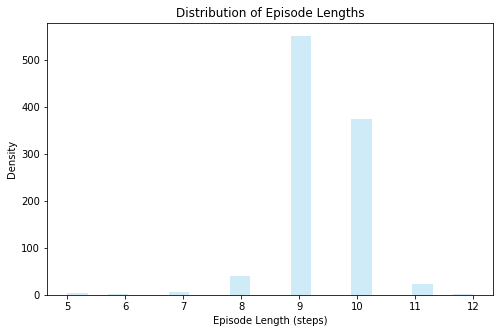

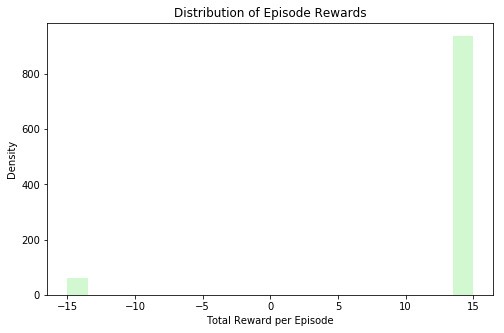

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.distplot(episode_length, bins=20, color='skyblue', kde=False)
plt.title("Distribution of Episode Lengths")
plt.xlabel("Episode Length (steps)")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(8,5))
sns.distplot(reward_history, bins=20, color='lightgreen', kde=False)
plt.title("Distribution of Episode Rewards")
plt.xlabel("Total Reward per Episode")
plt.ylabel("Density")
plt.show()


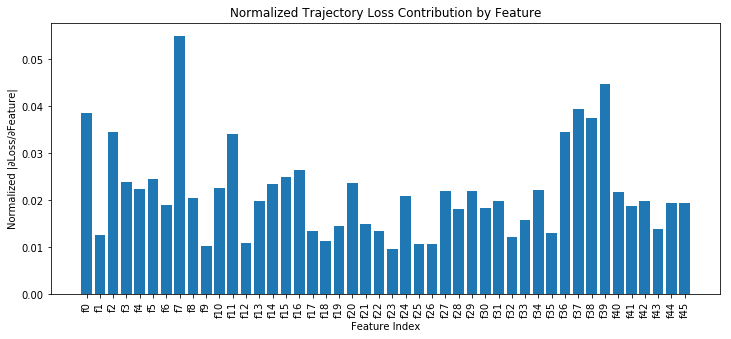

In [39]:
def compute_feature_loss_importance(model, memory, batch_size=256):
    """Computes normalized loss contribution by feature."""
    if len(memory) < batch_size:
        print("Not enough samples in memory.")
        return None, None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    states.requires_grad = True

    # Standard Double DQN target
    q_values = policy_net(states).gather(1, actions)
    next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
    next_q_values = target_net(next_states).gather(1, next_actions).detach()
    target_q = rewards + (gamma * next_q_values * (1 - dones))

    loss = (q_values - target_q).pow(2).mean()
    loss.backward(retain_graph=True)

    # Feature gradient magnitude
    grad_magnitudes = states.grad.abs().mean(dim=0).cpu().numpy()
    norm_grad = grad_magnitudes / (grad_magnitudes.sum() + 1e-8)

    feature_idx = np.arange(len(norm_grad))

    plt.figure(figsize=(12,5))
    plt.bar(feature_idx, norm_grad, color='salmon')
    plt.title("Normalized Trajectory Loss Contribution by Feature")
    plt.xlabel("Feature Index")
    plt.ylabel("Normalized |∂Loss/∂Feature|")
    feature_names = env.feature_names if hasattr(env, 'feature_names') else [f"f{i}" for i in range(state_size)]
    plt.bar(feature_names, norm_grad)
    plt.xticks(rotation=90)
    plt.show()

    return grad_magnitudes, norm_grad

# Run after training:
grad_mags, norm_grad = compute_feature_loss_importance(policy_net, memory)


In [40]:
import pandas as pd
success = reward_history.count(15)
print(success)
success_rate = success / num_episodes
print(success_rate)

938
0.938


In [ ]:
env.

distribution of episode length
distribution of reward history
trajectory loss and normalized trajectory loss by feature
